<a href="https://colab.research.google.com/github/EVRJSASTRY/NASSCOM-AI/blob/main/DAY4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

#Example:
#Consider two features: age (20–60) and salary (20,000–200,000).
#Without scaling, salary will dominate age due to its larger values.

data = np.array([[25, 50000],
                 [35, 100000],
                 [45, 150000]])


In [ ]:
# Standardization
standardized = StandardScaler().fit_transform(data)

print("Standardized:\n", standardized)




Standardized:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [ ]:
# Normalization
normalized = MinMaxScaler().fit_transform(data)
print("Normalized:\n", normalized)


Normalized:
 [[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)


Setup complete. pandas 2.2.2


In [ ]:
# -----------------------------------------------------------
# A SMALL, ALREADY-CLEAN DATASET (Part 1 did the cleaning)
# -----------------------------------------------------------
# Mixed columns: an unordered category (city), an ordered category
# (size), two numeric features on very different scales, and a target.
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df

,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. ONE-HOT ENCODING (for UNORDERED categories)
# -----------------------------------------------------------

# 'city' has no natural order -> one 0/1 column per category
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe

,city_delhi,city_mumbai,city_pune
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0
6,0,0,1
7,1,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. LABEL / ORDINAL ENCODING (for ORDERED categories)
# -----------------------------------------------------------

# 'size' has a real order: small < medium < large -> map to 0,1,2
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]

,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
# 1. One-hot encode just the 'city' column of the whole DataFrame
df_ohe = pd.get_dummies(df, columns=['city'], prefix='city')

print("One-Hot Encoded DataFrame:")
print(df_ohe)

# 2. Ordinal-encode 'size'
size_order = {'small': 0, 'medium': 1, 'large': 2}
df_ohe['size_code'] = df_ohe['size'].map(size_order)

print("\nSize Encoding:")
print(df_ohe[['size', 'size_code']])

# 3. Why one-hot is wrong for size / ordinal is wrong for city:
# One-hot encoding is wrong for 'size' because size has a natural order
# (small < medium < large). One-hot encoding loses this ordering information.
#
# Ordinal encoding is wrong for 'city' because cities have no natural order.
# Encoding pune=0, delhi=1, mumbai=2 incorrectly suggests that one city is
# greater or smaller than another, which has no real meaning.

One-Hot Encoded DataFrame:
     size  age  income  bought  size_code  city_delhi  city_mumbai  city_pune
0   small   25   38000       0          0       False        False       True
1   large   41   92000       1          2        True        False      False
2  medium   33   55000       0          1       False         True      False
3  medium   29   47000       0          1       False        False       True
4   small   52  120000       1          0        True        False      False
5   large   38   76000       1          2       False         True      False
6   large   46   88000       1          2       False        False       True
7   small   22   41000       0          0        True        False      False

Size Encoding:
     size  size_code
0   small          0
1   large          2
2  medium          1
3  medium          1
4   small          0
5   large          2
6   large          2
7   small          0


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. THE PROBLEM — FEATURES ON DIFFERENT SCALES
# -----------------------------------------------------------

# income (tens of thousands) dwarfs age (tens). A distance-based
# model would treat income as nearly all that matters.
print(df[['age', 'income']].describe().loc[['min', 'max', 'mean']])


        age    income
min   22.00   38000.0
max   52.00  120000.0
mean  35.75   69625.0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num = df[['age', 'income']]

z = StandardScaler().fit_transform(num)        # mean 0, std 1
m = MinMaxScaler().fit_transform(num)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=['age', 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=['age', 'income']).round(2).head(3))

Standardised (mean~0, std~1):
    age  income
0 -1.10   -1.16
1  0.54    0.82
2 -0.28   -0.54

Min-Max (range 0..1):
    age  income
0  0.10    0.00
1  0.63    0.66
2  0.37    0.21


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

income = df[['income']]   # 2D shape for sklearn

# 1. Standardise -> check mean ~0, std ~1
std_scaler = StandardScaler()
income_std = std_scaler.fit_transform(income)

print("Standardised Income:")
print("Mean =", round(income_std.mean(), 6))
print("Std  =", round(income_std.std(), 6))

# 2. Min-Max scale -> check min 0, max 1
mm_scaler = MinMaxScaler()
income_mm = mm_scaler.fit_transform(income)

print("\nMin-Max Scaled Income:")
print("Min =", income_mm.min())
print("Max =", income_mm.max())

# 3. Needs scaling: K-Nearest Neighbors (KNN), SVM, Logistic Regression
#    Doesn't need it: Decision Tree, Random Forest

Standardised Income:
Mean = -0.0
Std  = 1.0

Min-Max Scaled Income:
Min = 0.0
Max = 1.0000000000000002


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age', 'income']]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # FIT + transform on train
X_test_s  = scaler.transform(X_test)        # only TRANSFORM on test
print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))

train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [3.45e+01 6.90e+04]


In [ ]:
# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

# 2. Why fitting on all data is a problem:
# Fitting on all data uses information from the test set when calculating
# statistics such as mean and standard deviation. This causes data leakage
# because the preprocessing step has already "seen" the test data.
# As a result, model evaluation becomes overly optimistic and does not
# accurately represent performance on truly unseen data.
# The correct approach is:
#   1. Split into train and test sets.
#   2. Fit the scaler only on the training set.
#   3. Transform both train and test using the scaler learned from training.

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45e+01 6.90e+04]


In [ ]:
fe = df.copy()
# combine: income per year of age (a crude 'earning rate')
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)
# bin: turn continuous age into life-stage buckets
fe['age_group'] = pd.cut(fe['age'], bins=[0, 30, 45, 100],
                         labels=['young', 'mid', 'senior'])
fe[['age', 'income', 'income_per_age', 'age_group']]


,age,income,income_per_age,age_group
0,25,38000,1520.0,young
1,41,92000,2244.0,mid
2,33,55000,1667.0,mid
3,29,47000,1621.0,young
4,52,120000,2308.0,senior
5,38,76000,2000.0,mid
6,46,88000,1913.0,senior
7,22,41000,1864.0,young


In [ ]:
dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])
d = pd.DataFrame({'date': dates})
d['day_of_week'] = d['date'].dt.day_name()   # Monday, Tuesday, ...
d['month']       = d['date'].dt.month
d['is_weekend']  = d['date'].dt.dayofweek >= 5
d


,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:
import pandas as pd

ex = df.copy()

# 1. high_earner flag (income > median)
income_median = ex['income'].median()
ex['high_earner'] = ex['income'] > income_median

# 2. bin income into 3 buckets
ex['income_group'] = pd.cut(
    ex['income'],
    bins=3,
    labels=['low', 'mid', 'high']
)

# 3. show income + the new columns
print(ex[['income', 'high_earner', 'income_group']])

   income  high_earner income_group
0   38000        False          low
1   92000         True          mid
2   55000        False          low
3   47000        False          low
4  120000         True         high
5   76000         True          mid
6   88000         True          mid
7   41000        False          low


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = ['age', 'income']
cat_cols = ['city', 'size']

# scale the numbers, one-hot the categories — all in one object
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
pipe = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000))])
print(pipe)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'size'])])),
                ('model', LogisticRegression(max_iter=1000))])


In [ ]:
X = df[num_cols + cat_cols]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

pipe.fit(X_train, y_train)        # preprocessing fitted on TRAIN only — no leakage
acc = pipe.score(X_test, y_test)  # transforms test with train-fitted steps
print('Test accuracy:', round(acc, 2))
print('(small toy dataset — the point is the leak-free workflow, not the score)')


Test accuracy: 1.0
(small toy dataset — the point is the leak-free workflow, not the score)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

Xn = df[['age', 'income']]
yn = df['bought']

# 1. Pipeline: MinMaxScaler -> LogisticRegression
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LogisticRegression())
])

# 2. Split + fit on train
X_train, X_test, y_train, y_test = train_test_split(
    Xn,
    yn,
    test_size=0.25,
    random_state=0
)

pipe.fit(X_train, y_train)

# 3. Print test accuracy
print("Test Accuracy:", round(pipe.score(X_test, y_test), 3))

Test Accuracy: 1.0


In [ ]:
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')



Generated dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
df.info()   # column types + non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [ ]:
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

Missing values (%):
first_order_date    14.8
last_order_date     14.8
age                  7.0
gender               4.0
city                 2.0
signup_date          0.0
dtype: float64

Churn rate (target): 0.166
Customers with zero orders: 369


In [ ]:
# 1. Is customer_id unique?
print("Customer ID unique?:", df['customer_id'].is_unique)

# Alternative check
print("Duplicate customer IDs:",
      df['customer_id'].duplicated().sum())

# 2. Numeric summary
print("\nNumeric Summary:")
print(df.describe())

# 3. Three issues I can see:
# - Missing values exist in age, gender, and city columns.
# - Some customers have num_orders = 0 and total_spend = 0
#   (may represent dormant customers; needs business validation).
# - total_spend is likely highly right-skewed with a few very large
#   "whale" customers/outliers.
#
# Additional possible issues:
# - last_order_date is missing for customers with zero orders.
# - Churn classes are imbalanced (fewer churned customers than active customers).
# - Rare cities create a high-cardinality categorical feature.

Customer ID unique?: True
Duplicate customer IDs: 0

Numeric Summary:
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:00:00    18.000000     0.000000     0.000000   
2

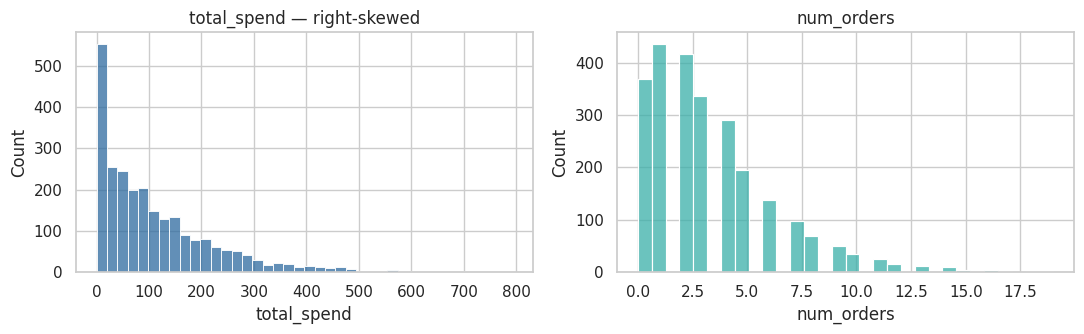

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()


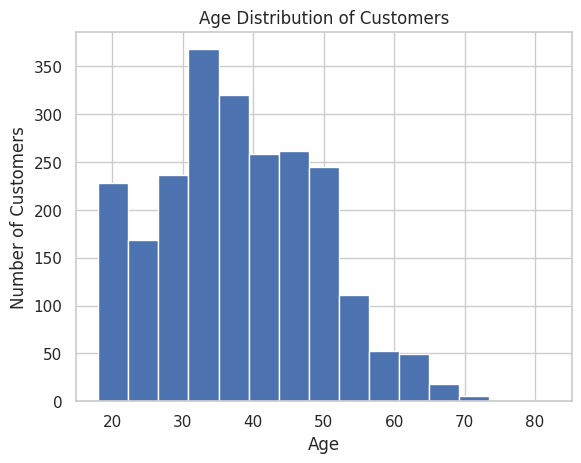

In [ ]:
import matplotlib.pyplot as plt

# 1. Histogram of age (drop missing values first)
df['age'].dropna().hist(bins=15)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

# 2. Shape description:
# - The age distribution is expected to be roughly bell-shaped (approximately normal)
#   because ages were generated from a normal distribution with mean ~38.
# - Most customers should fall between about 25 and 50 years old.
# - Very young (<18) and very old (>82) values should not appear because ages
#   were clipped to the range 18–82.
# - There may be slight spikes at 18 or 82 due to clipping, but no extreme outliers.

In [ ]:
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')



mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [ ]:
# 1. Skew of the two columns
print("Skew of num_orders   :", df['num_orders'].skew())
print("Skew of total_spend :", df['total_spend'].skew())

# Optional: compare mean and median
print("\nnum_orders")
print("Mean  :", df['num_orders'].mean())
print("Median:", df['num_orders'].median())

print("\ntotal_spend")
print("Mean  :", df['total_spend'].mean())
print("Median:", df['total_spend'].median())

# 2 & 3. Recommendation:
# - num_orders is likely positively (right) skewed because some customers place
#   many more orders than most customers.
# - total_spend is strongly positively skewed because of a few high-spending
#   "whale" customers.
#
# Recommendation:
# - Use the MEDIAN for total_spend because extreme spenders pull the mean upward.
# - For num_orders, the MEDIAN is usually also a better measure of a typical
#   customer when the distribution is right-skewed.
# - The mean is still useful for business totals and forecasting, but the
#   median better represents the "typical" customer.

Skew of num_orders   : 1.35301053502581
Skew of total_spend : 1.731732234873782

num_orders
Mean  : 3.2608
Median: 3.0

total_spend
Mean  : 112.2729
Median: 79.12


Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


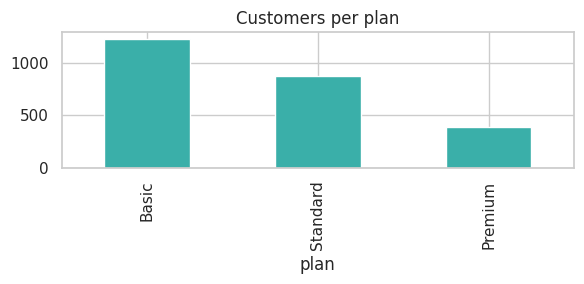

In [ ]:
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

Churn vs Retained Proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Imbalance Ratio (Retained / Churned): 5.02


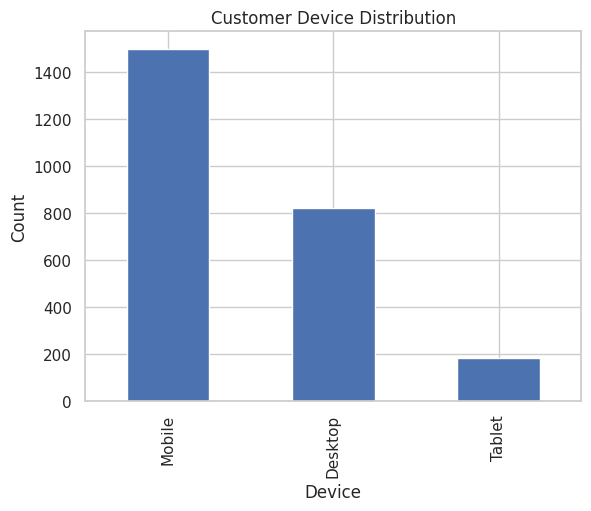

In [ ]:
import matplotlib.pyplot as plt

# 1. Churn vs retained proportions
churn_props = df['is_churned'].value_counts(normalize=True)

print("Churn vs Retained Proportions:")
print(churn_props)

# 2. Imbalance ratio (retained / churned)
retained = (df['is_churned'] == 0).sum()
churned = (df['is_churned'] == 1).sum()

imbalance_ratio = retained / churned

print("\nImbalance Ratio (Retained / Churned):",
      round(imbalance_ratio, 2))

# 3. Bar chart of device
device_counts = df['device'].value_counts()

device_counts.plot(kind='bar')
plt.title('Customer Device Distribution')
plt.xlabel('Device')
plt.ylabel('Count')
plt.show()

# Comment:
# Mobile is expected to be the dominant category because the dataset
# generator assigns device probabilities as:
# Mobile = 60%, Desktop = 32%, Tablet = 8%.
# Therefore, the bar chart should show Mobile with the highest count.

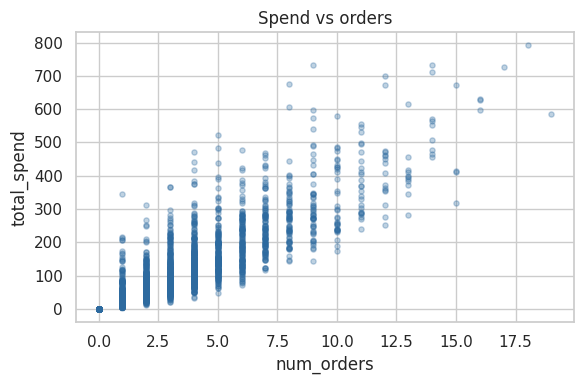

correlation: 0.864


In [ ]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))


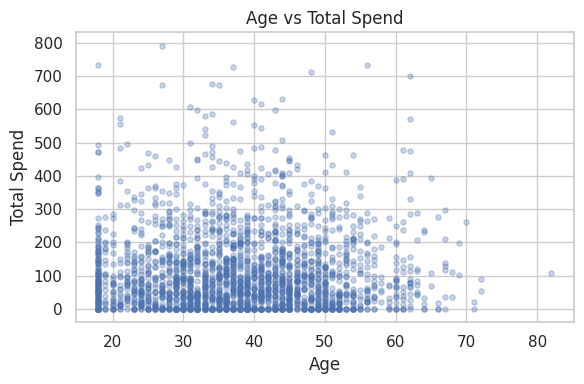

Correlation: 0.007


In [ ]:
import matplotlib.pyplot as plt

# 1. Scatter plot: age vs total_spend
plt.figure(figsize=(6, 4))

plt.scatter(
    df['age'],
    df['total_spend'],
    alpha=0.3,
    s=14
)

plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Total Spend')

plt.tight_layout()
plt.show()

# 2. Correlation
corr = df['age'].corr(df['total_spend'])

print("Correlation:", round(corr, 3))

# 3. Interpretation:
# If the correlation is close to 0, there is little or no linear
# relationship between age and total_spend.
#
# If it is moderately positive (e.g., 0.2–0.4), older customers
# tend to spend slightly more, but the relationship is weak.
#
# Regardless of the value, correlation does NOT imply causation.
# Even if older customers spend more on average, age itself may not
# be causing higher spending. Other factors such as income, plan,
# customer tenure, or shopping behavior may explain the relationship.

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_1257/3359928049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


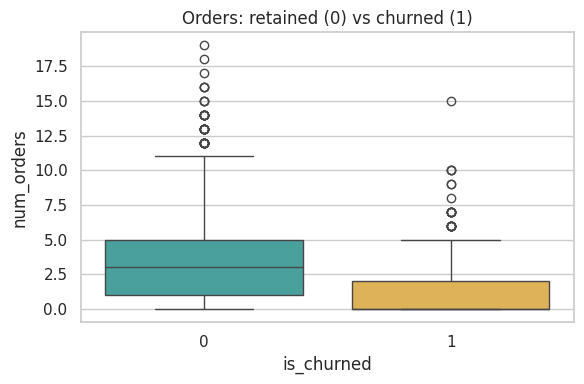

In [ ]:
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Mean support_tickets by churn status
print("Mean Support Tickets by Churn Status:")
print(
    df.groupby('is_churned')['support_tickets']
      .mean()
      .round(2)
)

# 2. Box plot of support_tickets by is_churned
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x='is_churned',
    y='support_tickets',
    palette=['#3AAFA9', '#F4B942']
)

plt.title('Support Tickets: Retained (0) vs Churned (1)')
plt.xlabel('is_churned')
plt.ylabel('support_tickets')
plt.show()

# 3. Is it a warning sign?
# Yes, support tickets appear to be a churn warning sign if the
# churned group (1) has a noticeably higher average and median
# number of support tickets than the retained group (0).
#
# This suggests that customers experiencing more issues or requiring
# more support are more likely to leave. However, support tickets
# alone do not cause churn; they are an indicator that customer
# dissatisfaction may be higher.

Mean Support Tickets by Churn Status:


NameError: name 'df' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


Generated dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


In [ ]:
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()

,customer_id,frequency,monetary,avg_order_value,recency_days,n_categories
0,CUST00003,1,39.17,39.17,405,1
1,CUST00004,1,2.74,2.74,729,1
2,CUST00005,4,133.80,33.45,15,3
3,CUST00006,1,23.36,23.36,45,1
4,CUST00007,2,73.70,36.85,684,2


In [ ]:
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 20)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


In [ ]:
import numpy as np
import pandas as pd

# Make sure order_date is datetime
tx['order_date'] = pd.to_datetime(tx['order_date'])

# 1. First & last order per customer -> active span in days
cust_span = tx.groupby('customer_id')['order_date'].agg(['min', 'max'])

cust_span['active_span_days'] = (
    cust_span['max'] - cust_span['min']
).dt.days

# Add order frequency
cust_span['frequency'] = tx.groupby('customer_id').size()

# 2. avg_days_between_orders = span / (frequency - 1)
cust_span['avg_days_between_orders'] = np.where(
    cust_span['frequency'] > 1,
    cust_span['active_span_days'] / (cust_span['frequency'] - 1),
    np.nan      # customers with 0 or 1 order
)

# Keep useful columns
cust_features = cust_span[['active_span_days',
                           'frequency',
                           'avg_days_between_orders']]

# 3. Merge onto df and show head
df2 = df.merge(
    cust_features,
    on='customer_id',
    how='left'
)

print(df2.head())

  customer_id signup_date first_order_date last_order_date   age gender  \
0   CUST00001  2021-04-19              NaT             NaT  31.0      F   
1   CUST00002  2023-07-31              NaT             NaT  54.0      F   
2   CUST00003  2023-03-07       2023-05-22      2023-05-22  43.0  Other   
3   CUST00004  2022-06-18       2022-07-02      2022-07-02  28.0      F   
4   CUST00005  2022-06-11       2022-09-18      2024-06-15  30.0      F   

        city      plan   device payment_method  ...  email_opt_in  is_churned  \
0    Chennai   Premium  Desktop           Card  ...             0           0   
1  Hyderabad  Standard  Desktop         Wallet  ...             0           1   
2       Pune   Premium   Mobile         Wallet  ...             0           0   
3       Pune  Standard  Desktop           Card  ...             1           0   
4     Mumbai  Standard   Mobile         Wallet  ...             0           0   

   frequency_x  monetary  avg_order_value  n_categories  recen

skew before: 1.73
skew after : -1.12


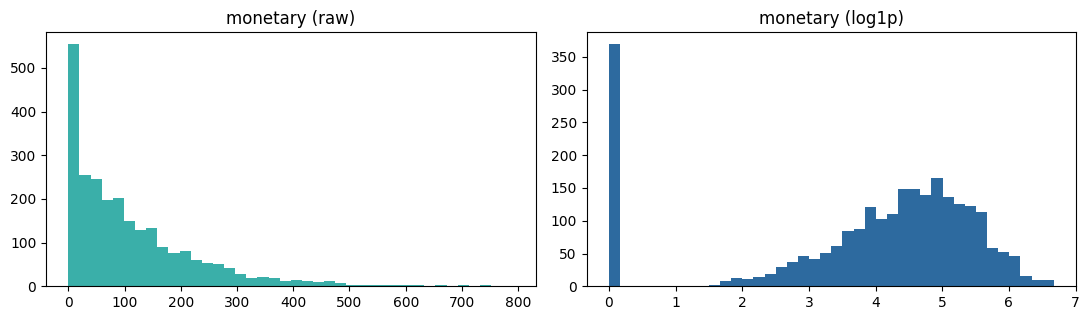

In [ ]:
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# 1. Skew of avg_order_value (after filling NaN with 0)
df['avg_order_value'] = df['avg_order_value'].fillna(0)

skew_before = df['avg_order_value'].skew()
print("Skew before log transform:", round(skew_before, 3))

# 2. Log-transform
df['aov_log'] = np.log1p(df['avg_order_value'])

# 3. Compare skew before and after
skew_after = df['aov_log'].skew()

print("Skew before:", round(skew_before, 3))
print("Skew after :", round(skew_after, 3))

if abs(skew_after) < abs(skew_before):
    print("✓ Skew moved closer to 0 after log transformation.")
else:
    print("✗ Skew did not decrease.")

Skew before log transform: 2.723
Skew before: 2.723
Skew after : -1.418
✓ Skew moved closer to 0 after log transformation.


In [ ]:

df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))


age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


In [ ]:
# 1. Bucket recency_days into business-friendly groups
df['recency_bucket'] = pd.cut(
    df['recency_days'],
    bins=[-1, 30, 90, 100000],
    labels=['active', 'lapsing', 'dormant']
)

# 2. Counts per bucket
print("Customers per Recency Bucket:")
print(df['recency_bucket'].value_counts(dropna=False))

# 3. Churn rate within each bucket
print("\nChurn Distribution by Recency Bucket:")
print(
    pd.crosstab(
        df['recency_bucket'],
        df['is_churned'],
        normalize='index'
    ).round(3)
)

Customers per Recency Bucket:
recency_bucket
dormant    1507
lapsing     531
active      462
Name: count, dtype: int64

Churn Distribution by Recency Bucket:
is_churned          0      1
recency_bucket              
active          0.933  0.067
lapsing         0.947  0.053
dormant         0.764  0.236


In [ ]:
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


In [ ]:
import numpy as np
import pandas as pd

# Make sure signup_date is datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])

# 1. tenure in months, then orders_per_month
tenure_months = (SNAPSHOT - df['signup_date']).dt.days / 30

df['orders_per_month'] = df['frequency'] / tenure_months

# 2. replace inf/NaN with 0
df['orders_per_month'] = (
    df['orders_per_month']
      .replace([np.inf, -np.inf], np.nan)
      .fillna(0)
)

# 3. top 5 customers by frequency
print(
    df.sort_values('frequency', ascending=False)
      [['customer_id',
        'frequency',
        'orders_per_month']]
      .head(5)
)

     customer_id  frequency  orders_per_month
237    CUST00238       19.0          0.758988
812    CUST00813       18.0          1.216216
562    CUST00563       17.0          0.753323
1918   CUST01919       16.0          0.660248
1199   CUST01200       16.0          0.919540


In [ ]:
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()


,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


In [ ]:
import pandas as pd

# Make sure first_order_date is datetime
df['first_order_date'] = pd.to_datetime(df['first_order_date'])

# 1. Days from first_order_date to SNAPSHOT
df['days_since_first_order'] = (
    SNAPSHOT - df['first_order_date']
).dt.days

# 2. Fill NaT-derived NaN with 0
df['days_since_first_order'] = (
    df['days_since_first_order']
      .fillna(0)
      .astype(int)
)

# 3. Show a few rows
print(
    df[['first_order_date', 'days_since_first_order']]
      .head(10)
)

  first_order_date  days_since_first_order
0              NaT                       0
1              NaT                       0
2       2023-05-22                     405
3       2022-07-02                     729
4       2022-09-18                     651
5       2024-05-16                      45
6       2021-10-04                    1000
7       2023-09-30                     274
8       2022-09-05                     664
9       2022-03-27                     826


In [ ]:
df = pd.get_dummies(df, columns=['plan', 'device', 'payment_method'],
                    drop_first=False, dtype=int)
print('columns after one-hot:', df.shape[1])
print([c for c in df.columns if c.startswith(('plan_', 'device_'))])

columns after one-hot: 41
['plan_Basic', 'plan_Premium', 'plan_Standard', 'device_Desktop', 'device_Mobile', 'device_Tablet']


In [ ]:
freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq).fillna(0)
print(df[['city', 'city_freq']].drop_duplicates().head(8))

          city  city_freq
0      Chennai   0.103265
1    Hyderabad   0.130612
2         Pune   0.082857
4       Mumbai   0.169796
5        Delhi   0.165306
10   Bengaluru   0.159184
13       Patna   0.013469
14  Coimbatore   0.016735


In [ ]:
# 1. Fill missing gender with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')

# 2. One-hot encode gender
gender_ohe = pd.get_dummies(
    df['gender'],
    prefix='gender',
    dtype=int
)

# 3. Show the new columns
print(gender_ohe.head())

# Optional: add them back to the DataFrame
df = pd.concat([df, gender_ohe], axis=1)

   gender_F  gender_M  gender_Other  gender_Unknown
0         1         0             0               0
1         1         0             0               0
2         0         0             1               0
3         1         0             0               0
4         1         0             0               0


In [ ]:
top_cities = df['city'].value_counts().head(7).index   # keep the 7 biggest
df['city_grouped'] = df['city'].where(df['city'].isin(top_cities), 'Other')
print('before:', df['city'].nunique(), 'cities')
print('after :', df['city_grouped'].nunique(), 'categories')
print(df['city_grouped'].value_counts())

before: 17 cities
after : 8 categories
city_grouped
Mumbai       416
Delhi        405
Bengaluru    390
Other        373
Hyderabad    320
Chennai      253
Pune         203
Kolkata      140
Name: count, dtype: int64


In [ ]:
# 1. One-hot encode city_grouped
city_ohe = pd.get_dummies(
    df['city_grouped'],
    prefix='city_grouped',
    dtype=int
)

# 2. Number of new city_grouped_* columns
print("Number of new columns:", city_ohe.shape[1])

# Optional: show column names
print("\nNew Columns:")
print(city_ohe.columns.tolist())

# Optional: preview
print("\nPreview:")
print(city_ohe.head())

# 3. Why group first:
# Grouping first reduces the number of categories and therefore the
# number of one-hot encoded columns. This:
# - Reduces dimensionality (fewer features).
# - Reduces sparsity (fewer mostly-zero columns).
# - Gives more observations per category, making patterns easier for
#   models to learn.
# - Prevents very rare cities from creating separate columns that
#   contribute little information and may cause overfitting.

Number of new columns: 8

New Columns:
['city_grouped_Bengaluru', 'city_grouped_Chennai', 'city_grouped_Delhi', 'city_grouped_Hyderabad', 'city_grouped_Kolkata', 'city_grouped_Mumbai', 'city_grouped_Other', 'city_grouped_Pune']

Preview:
   city_grouped_Bengaluru  city_grouped_Chennai  city_grouped_Delhi  \
0                       0                     1                   0   
1                       0                     0                   0   
2                       0                     0                   0   
3                       0                     0                   0   
4                       0                     0                   0   

   city_grouped_Hyderabad  city_grouped_Kolkata  city_grouped_Mumbai  \
0                       0                     0                    0   
1                       1                     0                    0   
2                       0                     0                    0   
3                       0                     0

In [ ]:
df['is_dormant'] = ((df['frequency'] == 0) | (df['recency_days'] > 180)).astype(int)
# a simple RFM score: rank each of R, F, M into 1-4 and combine
df['R_score'] = pd.qcut(-df['recency_days'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']   # 3..12
print(df[['recency_days', 'frequency', 'monetary', 'rfm_score', 'is_dormant']].head())
print('\nMean churn by RFM score:')
print(df.groupby('rfm_score')['is_churned'].mean().round(2))

   recency_days  frequency  monetary  rfm_score  is_dormant
0        9999.0        0.0      0.00          3           1
1        9999.0        0.0      0.00          3           1
2         405.0        1.0     39.17          5           1
3         729.0        1.0      2.74          3           1
4          15.0        4.0    133.80         10           0

Mean churn by RFM score:
rfm_score
3     0.58
4     0.19
5     0.13
6     0.09
7     0.07
8     0.10
9     0.08
10    0.08
11    0.04
12    0.05
Name: is_churned, dtype: float64


In [ ]:
# 1. high_value flag (top 20% of monetary)

threshold = df['monetary'].quantile(0.80)

df['high_value'] = (
    df['monetary'] >= threshold
).astype(int)

print("80th percentile threshold:", round(threshold, 2))

# 2. churn rate by high_value

print("\nChurn Rate by High-Value Segment:")
print(
    df.groupby('high_value')['is_churned']
      .mean()
      .round(3)
)

# Optional: customer counts
print("\nCustomer Counts:")
print(df['high_value'].value_counts())

# 3. Another domain feature I'd add:
# Days since last support ticket (or support ticket frequency in the
# last 90 days). Customers who recently raised multiple issues may
# be more dissatisfied and therefore more likely to churn.

80th percentile threshold: 189.87

Churn Rate by High-Value Segment:
high_value
0    0.194
1    0.052
Name: is_churned, dtype: float64

Customer Counts:
high_value
0    2000
1     500
Name: count, dtype: int64


In [ ]:
drop_cols = ['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'city', 'gender', 'age_group', 'city_grouped', 'is_churned']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = X.select_dtypes(include='number')   # keep numeric features only
y = df['is_churned']
print('Feature matrix:', X.shape)
print('All numeric? ', X.select_dtypes(exclude='number').empty)
print('Any missing? ', int(X.isna().sum().sum()))
print('\nEngineered features include:')
print([c for c in X.columns if c in ('monetary_log','recency_days','rfm_score',
       'tickets_per_order','tenure_days','city_freq','is_dormant')])

Feature matrix: (2500, 43)
All numeric?  True
Any missing?  175

Engineered features include:
['recency_days', 'monetary_log', 'tickets_per_order', 'tenure_days', 'city_freq', 'is_dormant', 'rfm_score']


In [ ]:
# Assume:
# X = feature DataFrame
# y = target (is_churned)

# 1. Fill remaining missing values with the median
X = X.fillna(X.median(numeric_only=True))

# 2. Correlation of each feature with y, sorted
corrs = (
    X.assign(churn=y)
     .corr(numeric_only=True)['churn']
     .drop('churn')
     .sort_values(key=abs, ascending=False)   # strongest first
)

print("Feature Correlations with Churn:")
print(corrs)

# 3. A feature that would be leakage:
# Example:
# "Account Closed Date"
#
# If a customer churns and the company records an account-closure
# date afterwards, using that feature would leak future information.
# The model would effectively be told who churned before making
# the prediction.

Feature Correlations with Churn:
recency_days                 0.515644
aov_log                     -0.488545
monetary_log                -0.474965
rfm_score                   -0.385565
n_categories                -0.355871
R_score                     -0.346636
M_score                     -0.339905
F_score                     -0.322597
is_dormant                   0.310526
spend_per_category          -0.289175
num_orders                  -0.282144
frequency                   -0.282144
avg_order_value             -0.281717
monetary                    -0.252546
total_spend                 -0.252546
days_since_first_order      -0.234489
orders_per_month            -0.166035
high_value                  -0.153193
support_tickets              0.068880
tickets_per_order           -0.048281
tenure_days                  0.038022
payment_method_Wallet       -0.024611
signup_dow                   0.024051
payment_method_Card          0.020432
gender_Other                 0.018652
signup_month     